In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

In [14]:
df=pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [15]:
df.info() # ALSO WE CAN DO DF.ISNULL().SUM() TO FIND MISSING VALUES

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [16]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


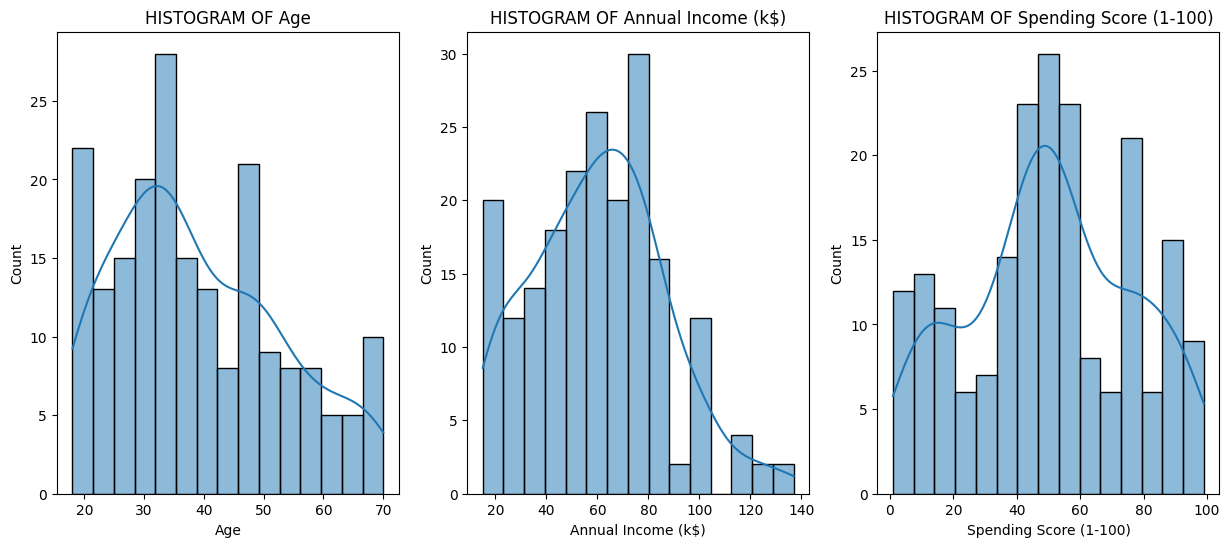

In [17]:
plt.figure(1,figsize=(15,6))
i=1
for x in ['Age','Annual Income (k$)','Spending Score (1-100)']:
    plt.subplot(1,3,i)
    sns.histplot(df[x],bins=15,kde=True)
    plt.title("HISTOGRAM OF {}".format(x))
    i=i+1

plt.show()

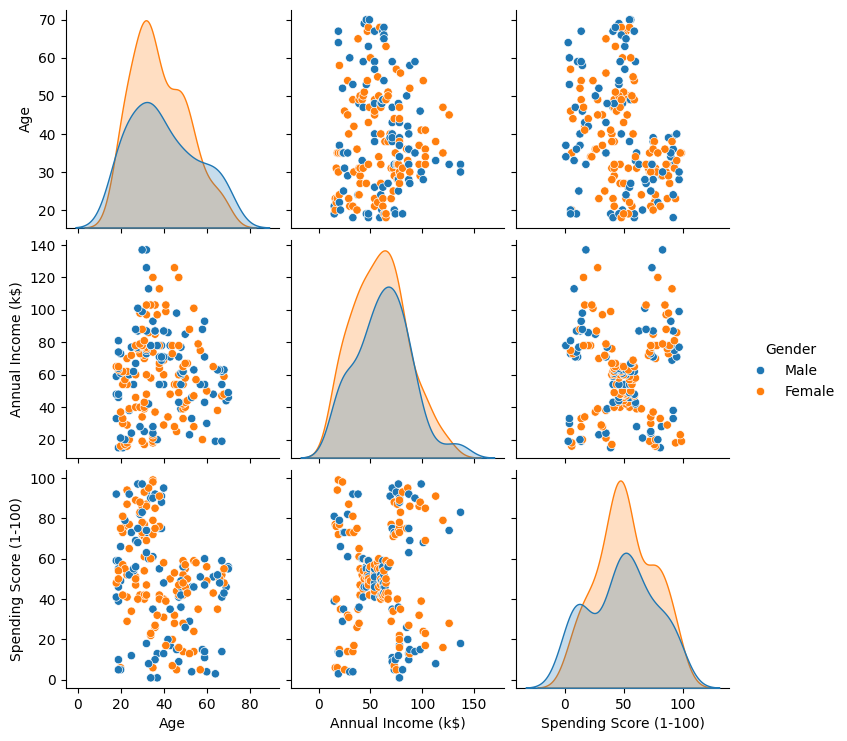

In [18]:
sns.pairplot(df,vars=['Age','Annual Income (k$)','Spending Score (1-100)'],hue='Gender')

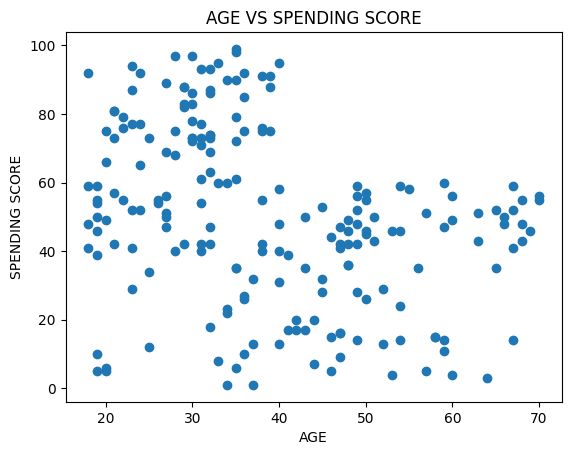

In [19]:
plt.scatter(df['Age'],df['Spending Score (1-100)'])
plt.title("AGE VS SPENDING SCORE")
plt.xlabel("AGE")
plt.ylabel("SPENDING SCORE")
plt.show()

In [20]:
X=df.drop(columns=['CustomerID','Annual Income (k$)','Gender'],axis=1)

s=StandardScaler()
scaled_X=s.fit_transform(X)

k_range=range(2,15)

inertia=[]
sil=[]

for i in k_range:
    km=KMeans(n_clusters=i,init='k-means++',n_init=10,max_iter=300,tol=0.0001,random_state=111,algorithm='lloyd')

    labels=km.fit_predict(scaled_X)

    inertia.append(km.inertia_)

    sil.append(silhouette_score(scaled_X,labels))

# SILHOUETTE SCORE IS BETWEEN -1 AND +1 ==> IF ITS -1 ==> THEN THE CLUSTER IS WIDELY SPREAD AND IF +1 ==> PERFECT CLUSTERING

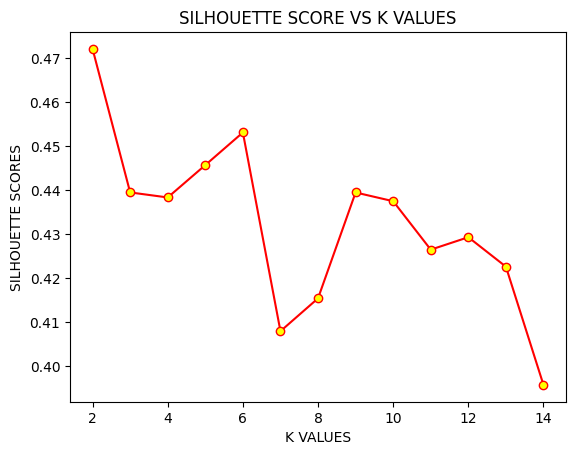

In [21]:
plt.title("SILHOUETTE SCORE VS K VALUES")
plt.plot(k_range,sil,marker='o',color='red',markerfacecolor='yellow')
plt.xlabel("K VALUES")
plt.ylabel("SILHOUETTE SCORES")
plt.show()

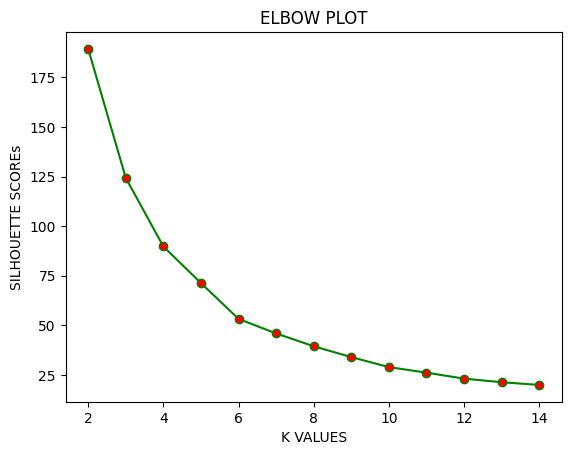

In [22]:
plt.title("ELBOW PLOT")
plt.plot(k_range,inertia,marker='o',color='green',markerfacecolor='red')
plt.xlabel("K VALUES")
plt.ylabel("SILHOUETTE SCOREs")
plt.show()

In [23]:
km=KMeans(n_clusters=6,init='k-means++',n_init=10,max_iter=300,tol=0.0001,random_state=111,algorithm='lloyd')

km.fit(scaled_X)

labels=km.labels_

centroids=km.cluster_centers_

In [24]:
X1=X.values

algorithm=(KMeans(n_clusters=6,init='k-means++',n_init=10,max_iter=300,tol=0.0001,random_state=111,algorithm='elkan'))

algorithm.fit(X1)

labels1=algorithm.labels_

centroids1=algorithm.cluster_centers_

In [25]:


h=0.02

x_min,x_max=X1[:,0].min() -1,X1[:,0].max()+1
y_min,y_max=X1[:,1].min() -1,X1[:,1].max()+1
XX,YY=np.meshgrid(np.arange(x_min,x_max,h),np.arange(y_min,y_max,h))
Z=algorithm.predict(np.c_[XX.ravel(),YY.ravel()])

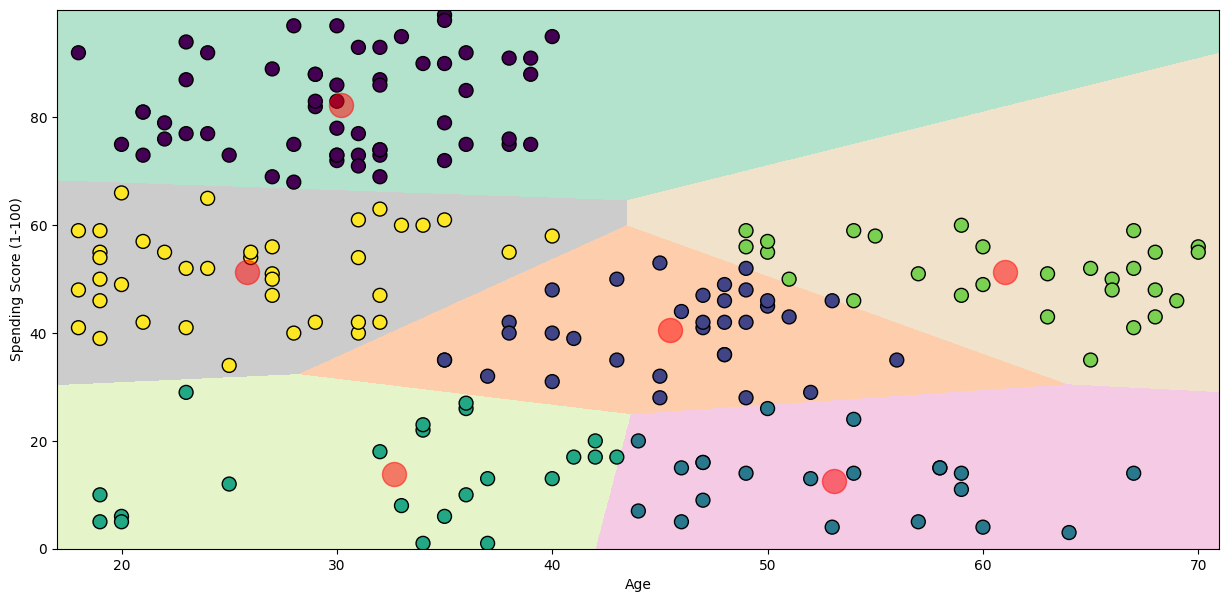

In [26]:
plt.figure(1, figsize=(15, 7))
plt.clf()


Z = Z.reshape(XX.shape)

plt.imshow(Z, interpolation='nearest', 
           extent=(XX.min(), XX.max(), YY.min(), YY.max()), 
           cmap=plt.cm.Pastel2, aspect='auto', origin='lower')

plt.scatter(x='Age', y='Spending Score (1-100)', data=df, c=labels1, s=100, edgecolors='black')

plt.scatter(x=centroids1[:, 0], y=centroids1[:, 1], s=300, c='red', alpha=0.5)

plt.xlabel("Age")
plt.ylabel("Spending Score (1-100)")

plt.show()